<a href="https://colab.research.google.com/github/ngonhatanhly-NNA/AI-Training/blob/main/week1_data_preparation_fairness_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install datasets

from datasets import load_dataset
dataset = load_dataset("LabHC/bias_in_bios")
df = pd.DataFrame(dataset['train'])
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-0ab65b32c47407(…):   0%|          | 0.00/64.9M [00:00<?, ?B/s]

data/test-00000-of-00001-5598c840ce8de1e(…):   0%|          | 0.00/24.9M [00:00<?, ?B/s]

data/dev-00000-of-00001-e6551072fff26949(…):   0%|          | 0.00/9.95M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/257478 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/99069 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/39642 [00:00<?, ? examples/s]

,hard_text,profession,gender
0,He is also the project lead of and major contr...,21,0
1,"She is able to assess, diagnose and treat mino...",13,1
2,"Prior to law school, Brittni graduated magna c...",2,1
3,He regularly contributes to India’s First Onli...,11,0
4,He completed his medical degree at Northwester...,21,0


In [ ]:
print(df.info())
print(df.columns)
df.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257478 entries, 0 to 257477
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   hard_text   257478 non-null  object
 1   profession  257478 non-null  int64 
 2   gender      257478 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.9+ MB
None
Index(['hard_text', 'profession', 'gender'], dtype='object')


,hard_text,profession,gender
85320,He received his law degree from Pennsylvania S...,2,0
202331,From 1985 to 1988 he was in the School of Natu...,21,0
18953,"Before receiving her teaching credential, she ...",26,1


In [ ]:
df = df.drop_duplicates()
print(df.isnull().sum()) # Check for missing value
df = df.dropna(subset=["hard_text", "gender"])

hard_text     0
profession    0
gender        0
dtype: int64


In [ ]:
# Clean the dataset
df["hard_text"] = df["hard_text"].str.replace(r'[^a-zA-Z\s]', '', regex=True)

df["hard_text"] = df["hard_text"].str.lower()
df["hard_text"] = df["hard_text"].str.strip()
df["hard_text"].sample(3)

,hard_text
241408,his research interests include theoretical nuc...
7327,her weapon of choice is a canon d and a no non...
175874,mr loughrey completed his nursing education at...


gender
0    138553
1    118563
Name: count, dtype: int64


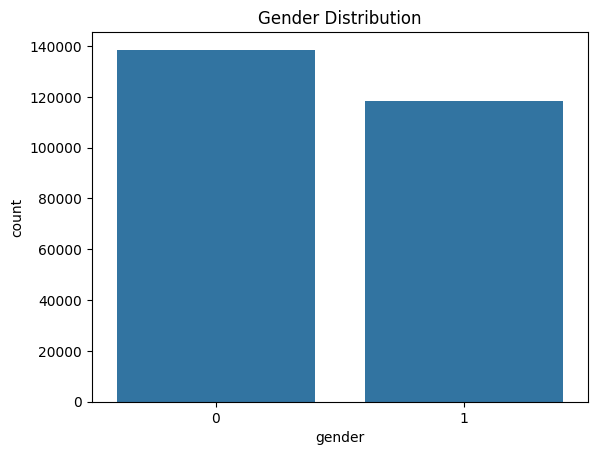

In [ ]:
# Analyze fairness in initial step (gender balance)
print(df["gender"].value_counts())

#Visualize
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()
#

In [ ]:
# Train and test
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

train, test = train_test_split(df, test_size=0.2, stratify=df["gender"], random_state=42)
print(train.shape, test.shape)

(205692, 3) (51424, 3)


In [ ]:
# Save to csv
train.to_csv("biosbias_train_cleaned.csv", index=False)
test.to_csv("biosbias_test_clean", index=False)

WEEK 2: PIPLINE NLP and Scikit fudamental

In [ ]:
!pip install scikit-learn --quiet
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [ ]:
X = df["hard_text"] # Text input
y = df["gender"] # Categorize

# Split train/test for repetition
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# TF-IDF vectorize (Tokenize and Vectorize)
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print(X_train_tfidf.shape)


(205692, 256226)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Using RegressionLogistic
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)

# Prefiction
y_pred = clf.predict(X_test_tfidf)
# Evaluate
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00     27711
           1       1.00      0.99      1.00     23713

    accuracy                           1.00     51424
   macro avg       1.00      1.00      1.00     51424
weighted avg       1.00      1.00      1.00     51424

[[27697    14]
 [  140 23573]]


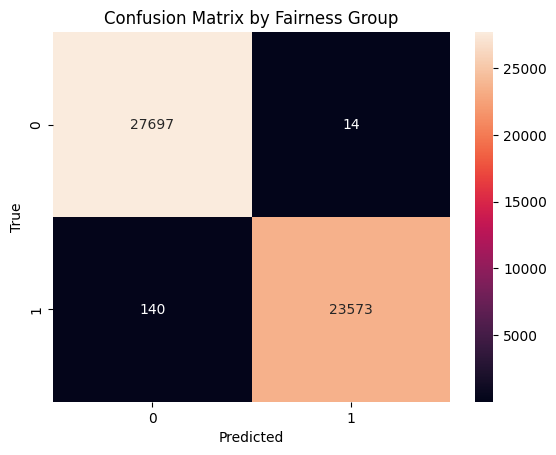

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix by Fairness Group')
plt.show()
